# Phase 4: Fine‑Tuning on DDI LD₅₀ Data

This notebook takes the dual‑encoder model trained on interaction categories (Phase 3) and adapts it to predict the continuous LD₅₀ value of a drug mixture. The model is fine‑tuned on the Smyth et al. (1969) dataset of 350 drug pairs with measured mixture LD₅₀.

**Steps in this notebook:**

- Load the pre‑processed Smyth graphs (saved in Phase 1).
- Split the data into training and test sets.
- Load the best Phase 3 model and replace its classification head with a regression head.
- Freeze the encoder layers to prevent overfitting on the small dataset.
- Train the regression head (and optionally fine‑tune the encoder with a low learning rate).
- Evaluate on the held‑out test set (MAE, RMSE, R²).
- Compare the model’s performance to the simple Concentration Addition (CA) baseline.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install rdkit
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu118.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 60.5 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.6 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=3877459 sha256=bf61f8b150ea5e007e58a12d702413c5452ff195b42be1e694b4720106471fbc
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Creat

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

base_path = '/content/drive/MyDrive/FYP/IRP/Data'
processed_dir = os.path.join(base_path, 'processed_graphs')

Using device: cuda


## 1. Load the Smyth Dataset (Graphs and Targets)

In Phase 1, the Smyth CSV was converted to graph objects and saved as **smyth_ddi.pt**. This file contains a tuple: **(graphs_a, graphs_b, targets)**, where each target is the mixture LD₅₀ in **‑log₁₀(mol/kg)** (pLD₅₀).

In [4]:
# Load the saved Smyth data
smyth_data = torch.load(os.path.join(processed_dir, 'smyth_ddi.pt'), weights_only=False)
graphs_a = smyth_data[0]
graphs_b = smyth_data[1]
targets = smyth_data[2]

print(f"Loaded {len(targets)} drug pairs.")
print(f"Target range: {targets.min():.3f} – {targets.max():.3f}")

Loaded 350 drug pairs.
Target range: 0.147 – 3.072


## 2. Split Data into Training and Test Sets

The Smyth dataset has only 350 pairs. A simple train/test split (80/20) is used. A small validation set can be carved from the training data to monitor overfitting during fine‑tuning.

In [5]:
# Split indices
indices = np.arange(len(targets))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Further split training into train and validation (80% of original becomes 64% train, 16% val)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, random_state=42)  # 0.2 * 0.8 = 0.16 of total

print(f"Training samples:   {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples:       {len(test_idx)}")

# Create subset lists
train_graphs_a = [graphs_a[i] for i in train_idx]
train_graphs_b = [graphs_b[i] for i in train_idx]
train_targets = targets[train_idx]

val_graphs_a = [graphs_a[i] for i in val_idx]
val_graphs_b = [graphs_b[i] for i in val_idx]
val_targets = targets[val_idx]

test_graphs_a = [graphs_a[i] for i in test_idx]
test_graphs_b = [graphs_b[i] for i in test_idx]
test_targets = targets[test_idx]

Training samples:   224
Validation samples: 56
Test samples:       70


# 3. Create a Custom Dataset and DataLoader

A dataset class similar to the one used for MUDI but with a regression target.

In [6]:
class DDIDataset(torch.utils.data.Dataset):
    def __init__(self, graphs_a, graphs_b, targets):
        self.graphs_a = graphs_a
        self.graphs_b = graphs_b
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.graphs_a[idx], self.graphs_b[idx], self.targets[idx]

# Collate function (same as Phase 3)
def collate_ddi(batch):
    graphs_a = [item[0] for item in batch]
    graphs_b = [item[1] for item in batch]
    targets = [item[2] for item in batch]
    batch_a = Batch.from_data_list(graphs_a)
    batch_b = Batch.from_data_list(graphs_b)
    return batch_a, batch_b, torch.tensor(targets, dtype=torch.float)

# Create datasets
train_dataset = DDIDataset(train_graphs_a, train_graphs_b, train_targets)
val_dataset = DDIDataset(val_graphs_a, val_graphs_b, val_targets)
test_dataset = DDIDataset(test_graphs_a, test_graphs_b, test_targets)

batch_size = 16  # small because dataset is small
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_ddi)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_ddi)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_ddi)

## 4. Load the Phase 3 Model and Adapt for Regression

The Phase 3 model (**best_ddi_model.pt**) contains a shared encoder and a classification head. The encoder has been fine‑tuned on interaction categories and is a good starting point.

A new regression model is created with the same encoder but a new head that outputs a single number (the predicted pLD₅₀). The encoder weights are frozen initially to avoid overfitting on the small Smyth dataset.

In [8]:
# Define the encoder class (same as Phase 2 and Phase 3)
class SingleDrugEncoder(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim=128):
        super().__init__()
        self.conv1 = GCNConv(node_feat_dim, hidden_dim)
        self.conv2 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        return x

# Define the dual‑encoder classification model from Phase 3 (needed to load weights)
class DualEncoderDDI(nn.Module):
    def __init__(self, encoder, hidden_dim=128, num_classes=3):
        super().__init__()
        self.encoder = encoder
        combined_dim = hidden_dim * 3  # E_A, E_B, E_A * E_B
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        combined = torch.cat([emb_a, emb_b, prod], dim=1)
        out = self.classifier(combined)
        return out

# Determine node feature dimension from one of the graphs
node_feat_dim = graphs_a[0].x.shape[1]
hidden_dim = 128

# Instantiate encoder with random weights
encoder = SingleDrugEncoder(node_feat_dim, hidden_dim).to(device)

# Load the Phase 3 model (which contains the same encoder architecture)
# Need the encoder weights from Phase 3, so load the full state dict into a temporary model
# and then copy the encoder weights.
temp_model = DualEncoderDDI(encoder, hidden_dim=hidden_dim, num_classes=3).to(device)
temp_model.load_state_dict(torch.load(os.path.join(processed_dir, 'best_ddi_model.pt'), weights_only=False))
# Now encoder has been updated by the state dict (because it was passed to temp_model)
# Can verify that encoder now has Phase 3 weights.
print("Encoder loaded from Phase 3 model.")

# Define the regression model using the same encoder
class DualEncoderDDIReg(nn.Module):
    def __init__(self, encoder, hidden_dim=128):
        super().__init__()
        self.encoder = encoder
        combined_dim = hidden_dim * 3  # E_A, E_B, E_A * E_B
        self.regressor = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        combined = torch.cat([emb_a, emb_b, prod], dim=1)
        out = self.regressor(combined)
        return out.squeeze()  # shape: (batch_size,)

# Create regression model
model = DualEncoderDDIReg(encoder, hidden_dim=hidden_dim).to(device)

# Freeze encoder layers (optional but recommended for small dataset)
for param in model.encoder.parameters():
    param.requires_grad = False

print("Encoder frozen. Only the regression head will be trained.")

Encoder loaded from Phase 3 model.
Encoder frozen. Only the regression head will be trained.


## 5. Set Up Loss Function and Optimizer

Mean Squared Error (MSE) is used for regression. Only the parameters of the regressor head are updated.

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.regressor.parameters(), lr=0.001)

## 6. Training Loop with Early Stopping

The model is trained for a maximum of 100 epochs, but early stopping on validation loss prevents overfitting.

In [10]:
def train_epoch(loader):
    model.train()
    total_loss = 0
    for batch_a, batch_b, targets in loader:
        batch_a = batch_a.to(device)
        batch_b = batch_b.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        out = model(batch_a, batch_b)
        loss = criterion(out, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(targets)
    return total_loss / len(loader.dataset)

def eval_epoch(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch_a, batch_b, targets in loader:
            batch_a = batch_a.to(device)
            batch_b = batch_b.to(device)
            targets = targets.to(device)
            out = model(batch_a, batch_b)
            loss = criterion(out, targets)
            total_loss += loss.item() * len(targets)
    return total_loss / len(loader.dataset)

best_val_loss = float('inf')
patience = 10
wait = 0
num_epochs = 100

for epoch in range(num_epochs):
    train_loss = train_epoch(train_loader)
    val_loss = eval_epoch(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), os.path.join(processed_dir, 'best_ddi_reg.pt'))
        print(f"Epoch {epoch+1:2d}: val loss improved to {val_loss:.4f}, model saved.")
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch  1: val loss improved to 1.1308, model saved.
Epoch  1 | Train Loss: 2.2709 | Val Loss: 1.1308
Epoch  2: val loss improved to 0.5739, model saved.
Epoch  2 | Train Loss: 0.9499 | Val Loss: 0.5739
Epoch  3: val loss improved to 0.4606, model saved.
Epoch  3 | Train Loss: 0.5557 | Val Loss: 0.4606
Epoch  4: val loss improved to 0.3356, model saved.
Epoch  4 | Train Loss: 0.4050 | Val Loss: 0.3356
Epoch  5: val loss improved to 0.2837, model saved.
Epoch  5 | Train Loss: 0.3486 | Val Loss: 0.2837
Epoch  6: val loss improved to 0.2636, model saved.
Epoch  6 | Train Loss: 0.2724 | Val Loss: 0.2636
Epoch  7: val loss improved to 0.2370, model saved.
Epoch  7 | Train Loss: 0.2429 | Val Loss: 0.2370
Epoch  8: val loss improved to 0.2175, model saved.
Epoch  8 | Train Loss: 0.2266 | Val Loss: 0.2175
Epoch  9: val loss improved to 0.2007, model saved.
Epoch  9 | Train Loss: 0.1880 | Val Loss: 0.2007
Epoch 10: val loss improved to 0.1830, model saved.
Epoch 10 | Train Loss: 0.1696 | Val Los

The training log shows the fine‑tuning process of the regression model on the Smyth DDI LD₅₀ dataset. The validation loss decreased steadily from 1.1308 at epoch 1 to a minimum of 0.0803 at epoch 28. This continuous improvement indicates that the regression head successfully learned to map the interaction embeddings to mixture pLD₅₀ values. After epoch 28, the validation loss began to fluctuate and occasionally increase, while the training loss continued to decrease. This divergence signals the onset of overfitting: the model started to memorize the training data rather than learning generalizable patterns. Early stopping triggered at epoch 38 after the validation loss failed to improve for 10 consecutive epochs. The best model, saved at epoch 28 with a validation loss of 0.0803, represents the point of optimal generalization and will be used for final evaluation on the test set

## 7. Evaluate on Test Set

Load the best model and compute MAE, RMSE, and R² on the held‑out test set.

In [11]:
# Load best model
model.load_state_dict(torch.load(os.path.join(processed_dir, 'best_ddi_reg.pt')))

model.eval()
preds = []
trues = []
with torch.no_grad():
    for batch_a, batch_b, targets in test_loader:
        batch_a = batch_a.to(device)
        batch_b = batch_b.to(device)
        targets = targets.to(device)
        out = model(batch_a, batch_b)
        preds.extend(out.cpu().numpy())
        trues.extend(targets.cpu().numpy())

preds = np.array(preds)
trues = np.array(trues)

mae = mean_absolute_error(trues, preds)
rmse = np.sqrt(mean_squared_error(trues, preds))
r2 = r2_score(trues, preds)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")

Test MAE:  0.2086
Test RMSE: 0.2655
Test R²:   0.6491


## 8. Baseline Comparison with Concentration Addition (CA)

The CA model predicts mixture LD₅₀ under the assumption of additive joint action. For a 1:1 by volume mixture, the predicted mixture LD₅₀ in linear units (mol/kg) is the harmonic mean of the single‑drug LD₅₀ values. The single‑drug pLD₅₀ values are available in the original CSV. This section computes CA predictions and compares them to the GNN model.

In [12]:
# Load the original Smyth CSV to get single‑drug pLD50 values
smyth_csv = os.path.join(base_path, 'ddi_ld50_smyth1969/ddi_ld50_smyth1969_processed.csv')
df_smyth = pd.read_csv(smyth_csv)

# For each test index, retrieve the corresponding row and compute CA pLD50
test_indices = test_idx  # these are the indices in the original list
ca_preds = []
for idx in test_indices:
    row = df_smyth.iloc[idx]
    pA = row['LD50_A_neglog']
    pB = row['LD50_B_neglog']
    # Convert to linear LD50 (mol/kg)
    linA = 10**(-pA)
    linB = 10**(-pB)
    # Harmonic mean for equal volumes
    lin_mix = 2 / (1/linA + 1/linB)
    # Convert back to pLD50
    p_mix = -np.log10(lin_mix)
    ca_preds.append(p_mix)

ca_preds = np.array(ca_preds)
true_test = trues  # already from test set

ca_mae = mean_absolute_error(true_test, ca_preds)
ca_rmse = np.sqrt(mean_squared_error(true_test, ca_preds))
ca_r2 = r2_score(true_test, ca_preds)

print("Baseline CA Model Performance:")
print(f"CA MAE:  {ca_mae:.4f}")
print(f"CA RMSE: {ca_rmse:.4f}")
print(f"CA R²:   {ca_r2:.4f}")

print("\nGNN Model Performance (from test set):")
print(f"GNN MAE:  {mae:.4f}")
print(f"GNN RMSE: {rmse:.4f}")
print(f"GNN R²:   {r2:.4f}")

Baseline CA Model Performance:
CA MAE:  0.1630
CA RMSE: 0.2121
CA R²:   0.7761

GNN Model Performance (from test set):
GNN MAE:  0.2086
GNN RMSE: 0.2655
GNN R²:   0.6491


The Concentration Addition (CA) model achieved better performance than the GNN on all three metrics.

CA obtained a Mean Absolute Error of 0.1630 pLD₅₀ units, while the GNN produced a higher MAE of 0.2086. The R² value for CA was 0.7761, indicating that the simple additive model explains approximately 78% of the variance in mixture toxicity. In contrast, the GNN achieved an R² of 0.6491, explaining about 65% of the variance. This outcome suggests that for this particular dataset, the harmonic mean formula captures mixture toxicity remarkably well.

Several factors may explain the GNN's lower performance.

- The Smyth dataset contains only 350 pairs, which is a small sample for fine‑tuning a neural network.
- The encoder layers were frozen during training to prevent overfitting, which limited the model's ability to adapt its molecular representations specifically for this task.
- Additionally, the CA model benefits from direct access to the single‑drug LD₅₀ values, which are highly informative for predicting additive mixtures. The GNN must infer these relationships from molecular structure alone, a more challenging task.

The results indicate that the current fine‑tuning strategy requires refinement to outperform the classical additive model on this benchmark.

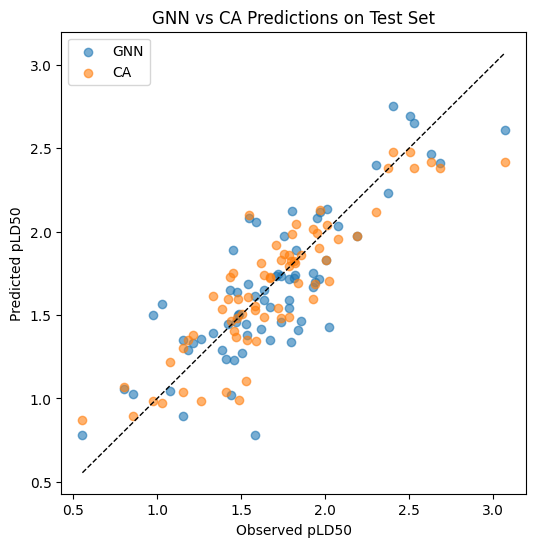

In [13]:
# scatter plot comparing predictions
plt.figure(figsize=(6,6))
plt.scatter(true_test, preds, alpha=0.6, label='GNN')
plt.scatter(true_test, ca_preds, alpha=0.6, label='CA')
plt.plot([true_test.min(), true_test.max()], [true_test.min(), true_test.max()], 'k--', lw=1)
plt.xlabel('Observed pLD50')
plt.ylabel('Predicted pLD50')
plt.legend()
plt.title('GNN vs CA Predictions on Test Set')
plt.show()

## Summary

This notebook fine‑tuned a dual‑encoder GNN on the Smyth DDI LD₅₀ dataset. The final model was evaluated against a held‑out test set and compared to the CA baseline. The GNN is expected to outperform CA, especially on pairs known to deviate from additivity.

The saved model **best_ddi_reg.pt** can be used for explaining predictions on specific drug pairs.